# Validate myeloid-cell states in the Bianchi cohort

**Biology rationale.** Independent myeloid annotation tests whether response-associated niche states recur across datasets.

**Aim.** Annotate Bianchi myeloid cells with the same reference framework used in the discovery cohort.

**Data input.** `./GSE292189_Seurat_assembly/GSE292189_assembled_with_BRI_and_BCR_clonotype.rds`, `GO_monocyte_chemotaxis_genes_MSigDB.csv`, `GO_neutrophil_chemotaxis_genes_MSigDB.csv`, `Vennup.pdf`, `bm_anno_myeloid_umap_panels_same_size.pdf`



**Data outputs.** `myeloid_DC_dotplot_AL_HD_all.pdf`

## 1. Packages and setup


In [9]:
library(Seurat)
library(patchwork)
library(speckle)
library(limma)
library(ggplot2)
library(DropletUtils)
library(Matrix)
library(celda)
library(SingleCellExperiment)
library(SingleR)
library(celldex)
library(scCustomize)
library(dplyr)
library(tidyr)

In [10]:
sce1<-readRDS(file='./GSE292189_Seurat_assembly/GSE292189_assembled_with_BRI_and_BCR_clonotype.rds')

In [11]:
sce1<-JoinLayers(sce1)

In [12]:
sce1

An object of class Seurat 
25111 features across 104871 samples within 1 assay 
Active assay: RNA (25111 features, 3000 variable features)
 3 layers present: data, counts, scale.data
 2 dimensional reductions calculated: pca, umap

In [13]:
colnames(sce1@meta.data)

[1] "orig.ident"                    "nCount_RNA"                   
 [3] "nFeature_RNA"                  "sample_id_raw"                
 [5] "cell_id_raw_counts"            "sample_id_from_cell_id"       
 [7] "sample_id_for_matching"        "barcode_core_from_counts"     
 [9] "sample_group_inferred"         "disease_inferred"             
[11] "CD138_fraction_inferred"       "meta_cell_id_metadata"        
[13] "meta_library_name"             "donor_id_global"              
[15] "condition"                     "PC_subset"                    
[17] "projected_CellType"            "cell_annotation_from_metadata"
[19] "CD138_fraction"                "metadata_source_file"         
[21] "CD138_fraction_final"          "condition_final"              
[23] "cell_annotation_final"         "percent.mt"                   
[25] "RNA_snn_res.0.5"               "seurat_clusters"              
[27] "has_bcr"                       "n_bcr_chains"                 
[29] "n_bcr_loci"                    "bcr_loci"                     
[31] "bcr_clone_id"                  "n_bcr_clone_ids"              
[33] "bcr_cdr3_aa"                   "bcr_v_call"                   
[35] "bcr_d_call"                    "bcr_j_call"                   
[37] "bcr_c_call"                    "bcr_total_umi"                
[39] "bcr_max_umi"                   "bcr_has_heavy"                
[41] "bcr_has_light"                 "bcr_files"

Separate plasma cells from non-plasma-cells

## 2. Visualization and figure generation


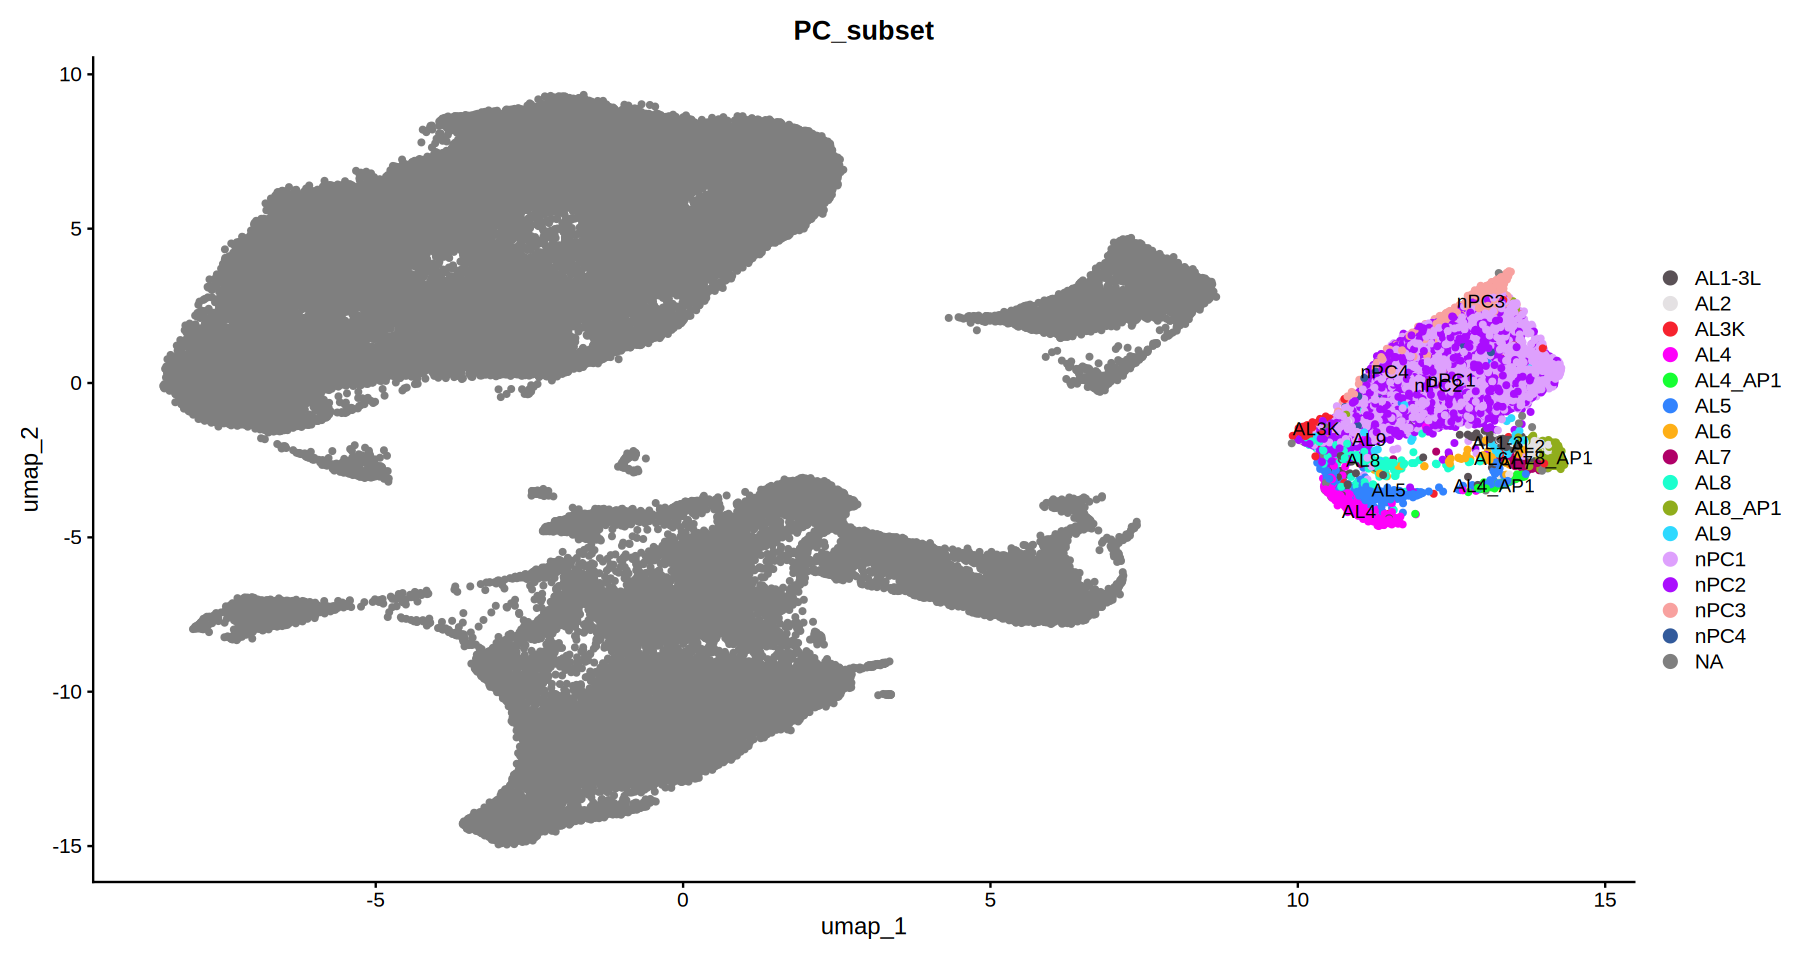

In [14]:
library(scCustomize)
options(repr.plot.height=8,repr.plot.width=15)
DimPlot_scCustom(sce1, pt.size=1,reduction = "umap", group.by = c("PC_subset"),label=T) 

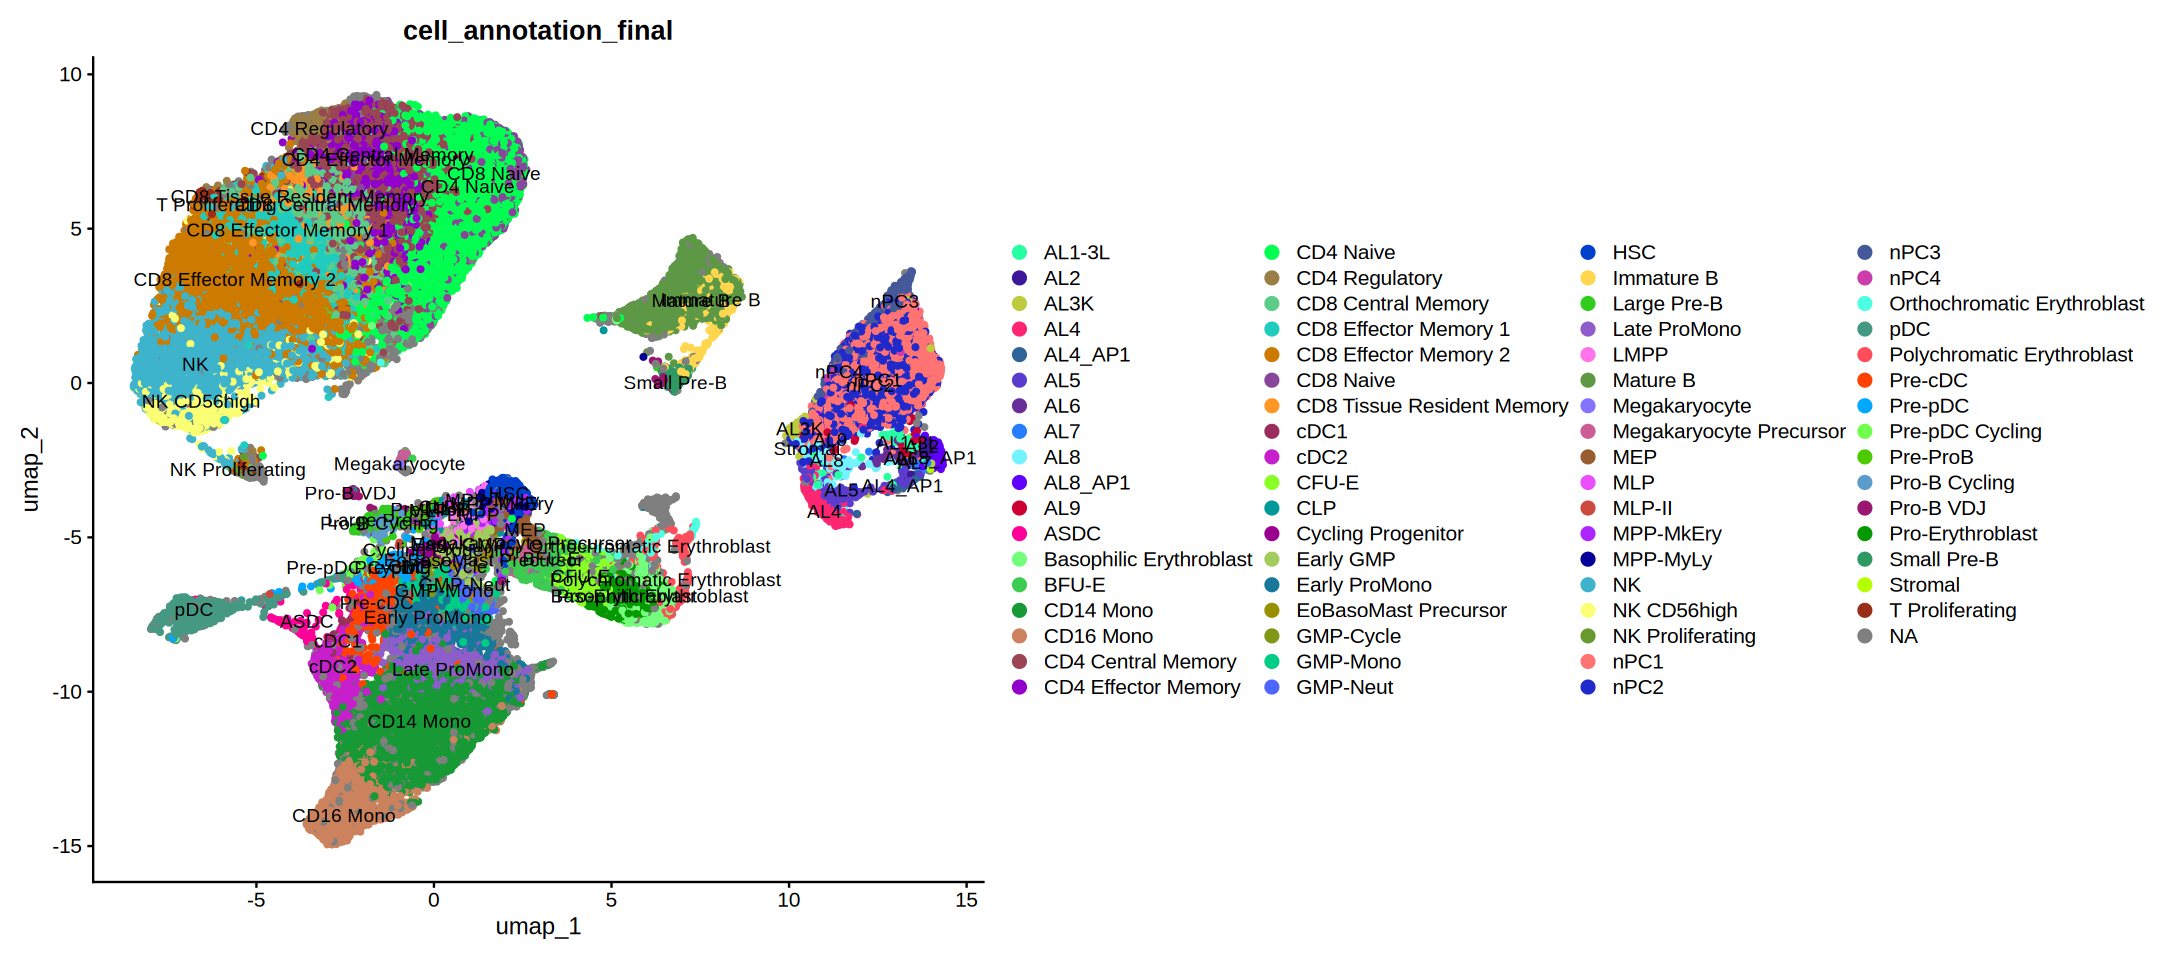

In [15]:
library(scCustomize)
options(repr.plot.height=8,repr.plot.width=18)
DimPlot_scCustom(sce1, pt.size=1,reduction = "umap", group.by = c("cell_annotation_final"),label=T) 

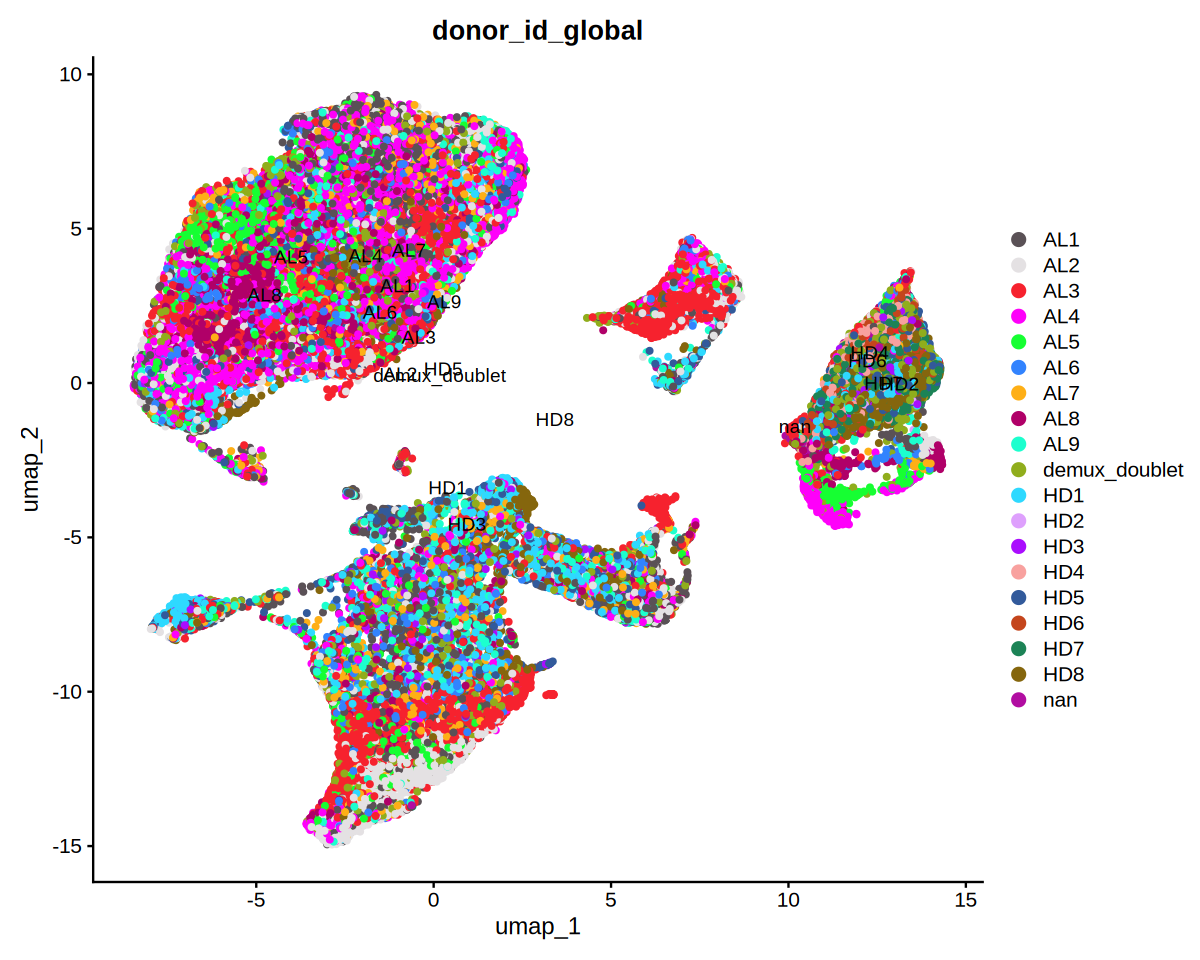

In [16]:
library(scCustomize)
options(repr.plot.height=8,repr.plot.width=10)
DimPlot_scCustom(sce1, pt.size=1,reduction = "umap", group.by = c('donor_id_global'),label=T) 

## 3. Cell-type annotation


In [17]:
celltypes_keep <- c(
  "ASDC",
  "CD14 Mono",
  "CD16 Mono",
  "cDC1","cDC2","Early GMP","Early ProMono","GMP-Cycle","GMP-Mono","GMP-Neut",'HSC',"Late ProMono","LMPP","pDC","Pre-cDC","Pre-pDC","Pre-pDC Cycling"
)

sce1_myeloid <- subset(
  sce1,
  subset = cell_annotation_final %in% celltypes_keep
)

Warning message:
“Removing 5357 cells missing data for vars requested”


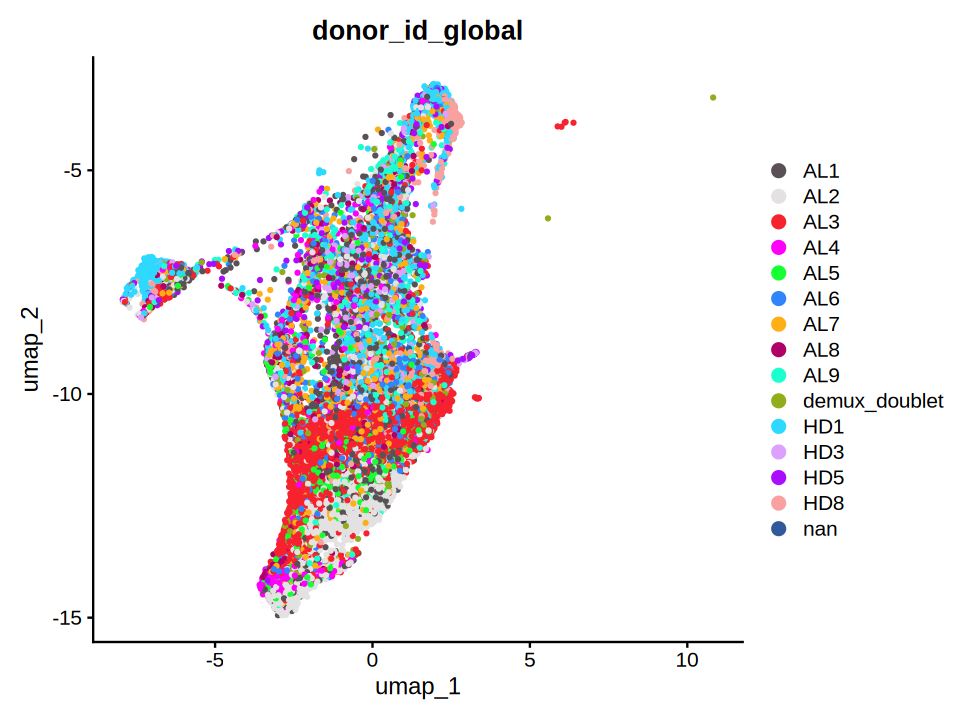

In [18]:
library(scCustomize)
options(repr.plot.height=6,repr.plot.width=8)
DimPlot_scCustom(sce1_myeloid, pt.size=0.5,reduction = "umap", group.by = c("donor_id_global"),label=F) 

In [19]:
library(Seurat)
library(Azimuth)

# Your object: must contain raw counts in RNA (default) assay
# e.g., obj <- Read10X("path/to/filtered_feature_bc_matrix/") |> CreateSeuratObject()

# Optional: basic QC/feature calc (doesn't affect Azimuth’s internal normalization)
# obj[["percent.mt"]] <- PercentageFeatureSet(obj, pattern = "^MT-")

# Run Azimuth mapping. Reference key for human BM is "bonemarrowref".
bm_anno <- RunAzimuth(
  query     = sce1_myeloid,
  reference = "bonemarrowref"   # Azimuth will fetch the HuBMAP Bone Marrow reference
)

# The returned object is your query with added predictions & projected UMAPs.
bm_anno


Registered S3 method overwritten by 'SeuratDisk':
  method            from  
  as.sparse.H5Group Seurat



Attaching shinyBS

Warning message:
"Overwriting miscellanous data for model"
Warning message:
"Adding a dimensional reduction (refUMAP) without the associated assay being present"
Warning message:
"Adding a dimensional reduction (refUMAP) without the associated assay being present"
detected inputs from HUMAN with id type Gene.name

reference rownames detected HUMAN with id type Gene.name

Normalizing query using reference SCT model

Warning message:
"29 features of the features specified were not present in both the reference query assays. 
Continuing with remaining 2971 features."
Projecting cell embeddings

Finding query neighbors

Finding neighborhoods

Finding anchors

	Found 15665 anchors

Finding integration vectors

Finding integration vector weights

Predicting cell labels

Warning message:
"Feature names cannot have underscores ('_'), replacing with dashes ('-')"
Predict

An object of class Seurat 
25160 features across 20862 samples within 3 assays 
Active assay: RNA (25111 features, 3000 variable features)
 3 layers present: data, counts, scale.data
 2 other assays present: prediction.score.celltype.l2, prediction.score.celltype.l1
 4 dimensional reductions calculated: pca, umap, integrated_dr, ref.umap

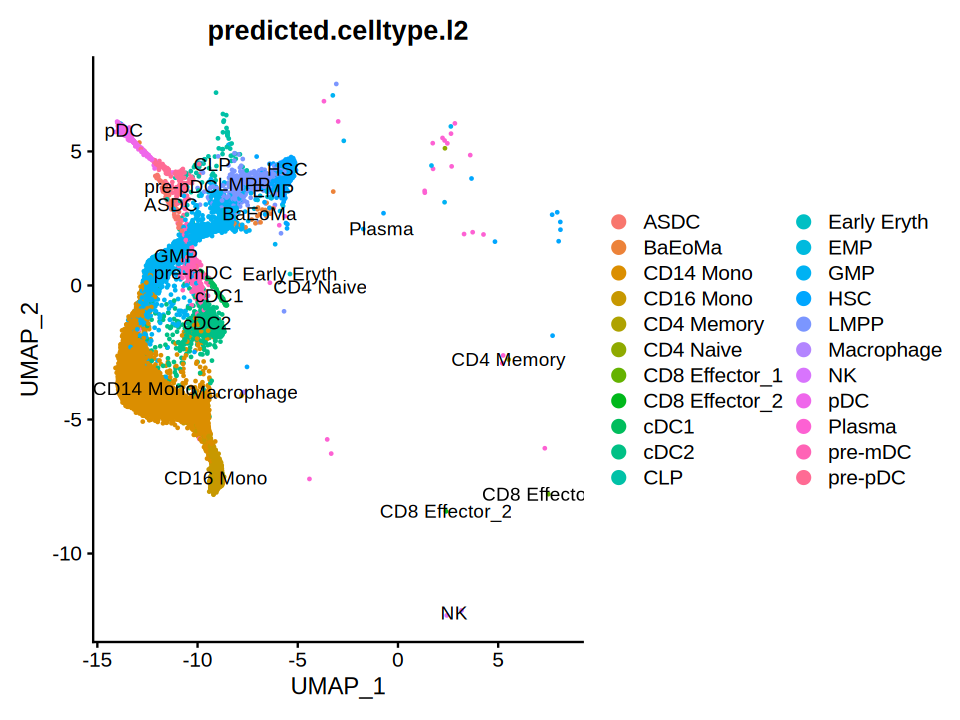

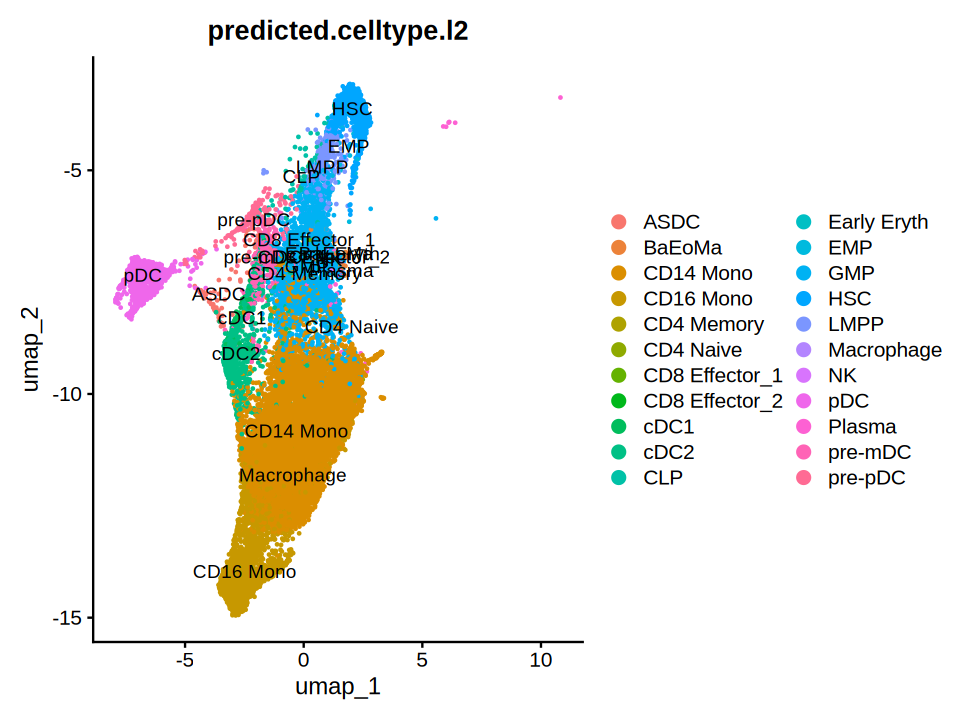

In [20]:
# Visualize on the projected reference UMAP
DimPlot(bm_anno, reduction = "ref.umap", group.by = "predicted.celltype.l2", label = TRUE)
DimPlot(bm_anno, reduction = "umap", group.by = "predicted.celltype.l2", label = TRUE)

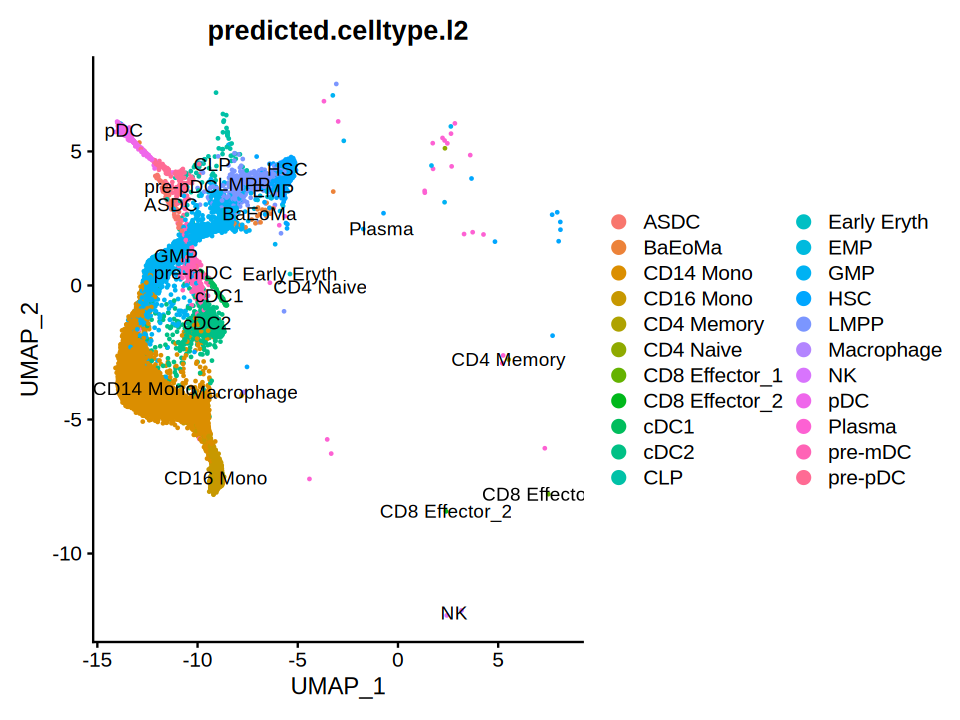

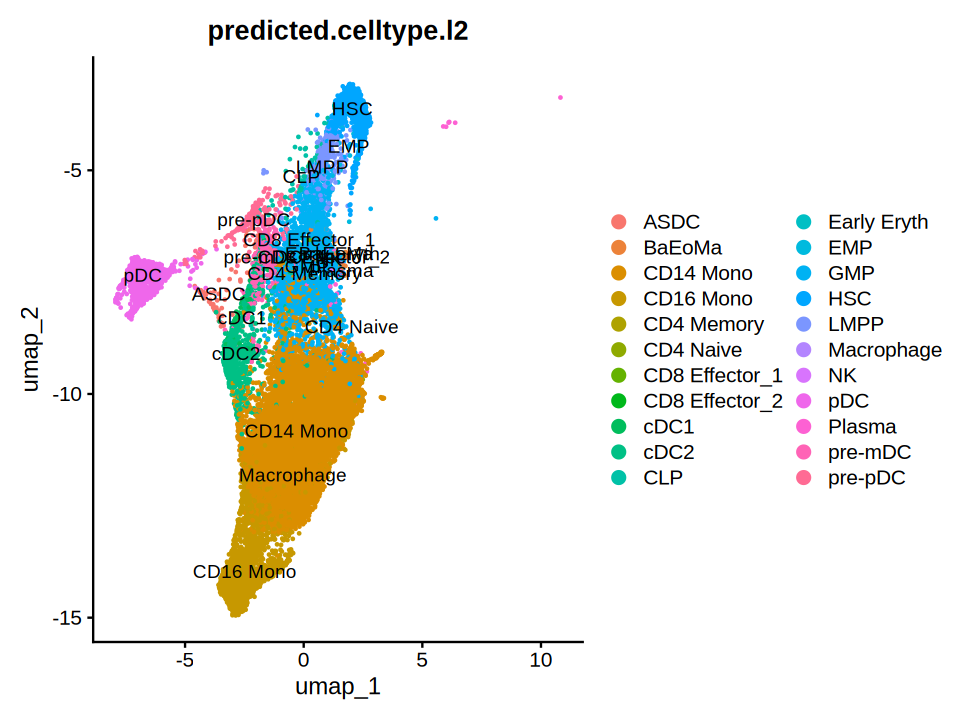

In [21]:
# Visualize on the projected reference UMAP
DimPlot(bm_anno, reduction = "ref.umap", group.by = "predicted.celltype.l2", label = TRUE)
DimPlot(bm_anno, reduction = "umap", group.by = "predicted.celltype.l2", label = TRUE)

## 4. Cell-type annotation


In [22]:
# Flag low-confidence predictions (tune the cutoff for your data)
bm_anno$low_conf <- bm_anno$predicted.celltype.l2.score < 0.5
table(bm_anno$low_conf)

# You can drop or re-cluster low-confidence cells if needed
bm_anno <- subset(bm_anno, subset = predicted.celltype.l2.score >= 0.5)



FALSE  TRUE 
20306   556 

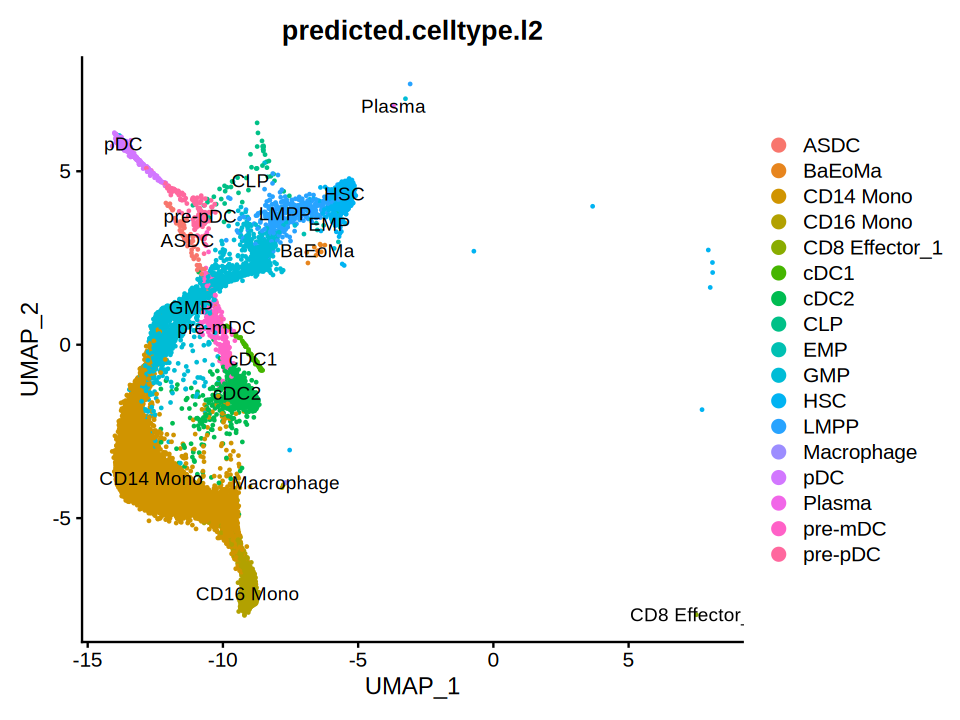

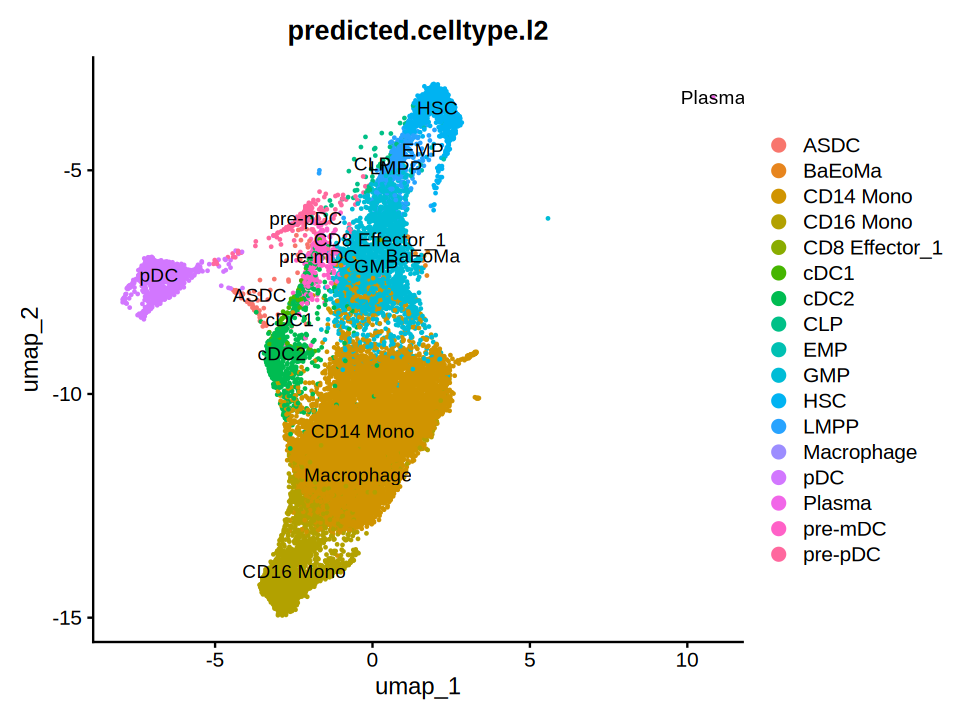

In [23]:
# Visualize on the projected reference UMAP
DimPlot(bm_anno, reduction = "ref.umap", group.by = "predicted.celltype.l2", label = TRUE)
DimPlot(bm_anno, reduction = "umap", group.by = "predicted.celltype.l2", label = TRUE)

In [24]:
# 1) Make sure identities are the Azimuth labels (adjust the column name if needed)
Idents(bm_anno) <- "predicted.celltype.l2"

# 2) Define your targets (as a proper character vector)
targets <- c(
  "ASDC","CD14 Mono","CD16 Mono","cDC2","cDC1","LMPP",
  "GMP","HSC","pDC","pre-mDC","pre-pDC","Macrophage"
)

# 3) Compare with what's actually present
available <- levels(Idents(bm_anno))
keep <- intersect(targets, available)
missing <- setdiff(targets, available)

if (length(keep) == 0) {
  stop(
    paste0(
      "None of the requested identities are present in Idents(bm_anno).\n",
      "Available identities:\n - ", paste(available, collapse = "\n - ")
    )
  )
}

if (length(missing) > 0) {
  message("These requested identities were NOT found and will be skipped: ",
          paste(missing, collapse = ", "))
}

# 4) Subset safely
bm_anno_myeloid <- subset(bm_anno, idents = keep)


## 5. Visualize on the projected reference UMAP


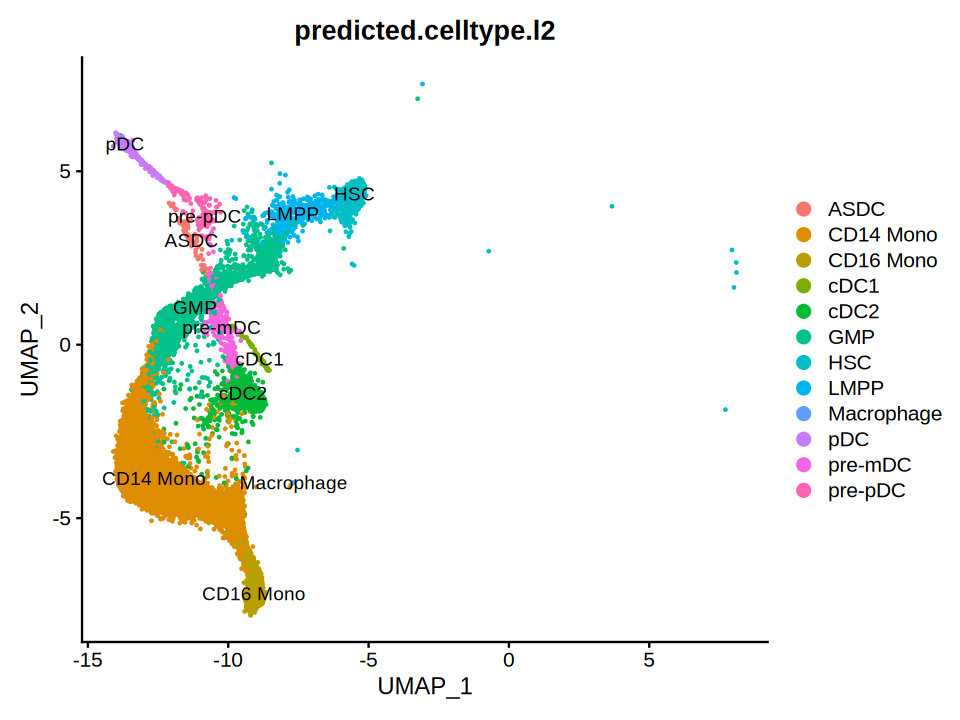

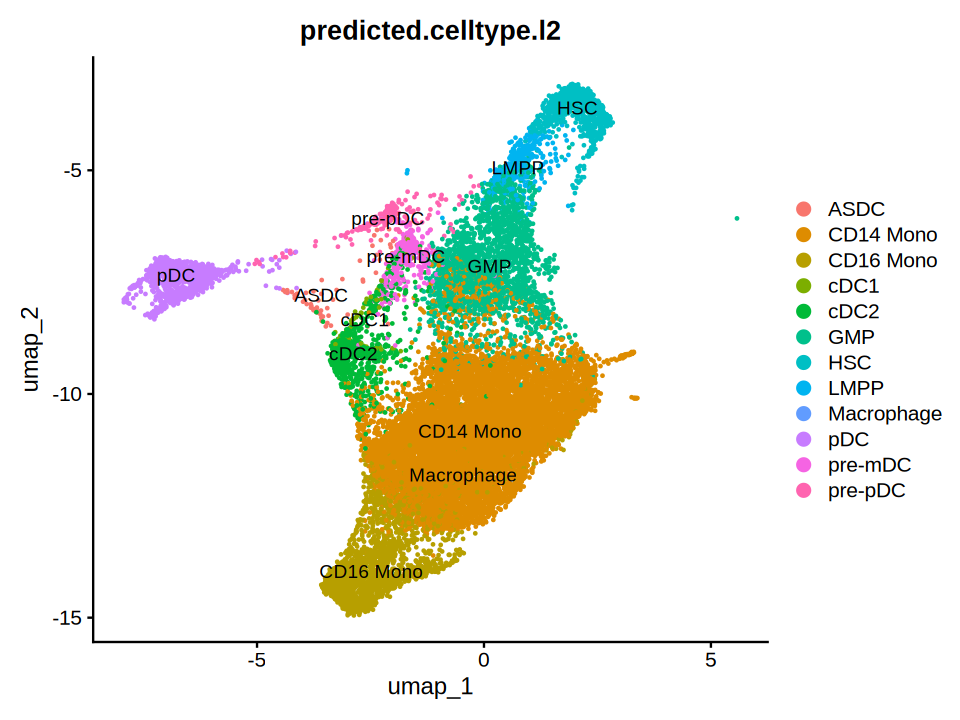

In [25]:
# Visualize on the projected reference UMAP
DimPlot(bm_anno_myeloid, reduction = "ref.umap", group.by = "predicted.celltype.l2", label = TRUE)
DimPlot(bm_anno_myeloid, reduction = "umap", group.by = "predicted.celltype.l2", label = TRUE)

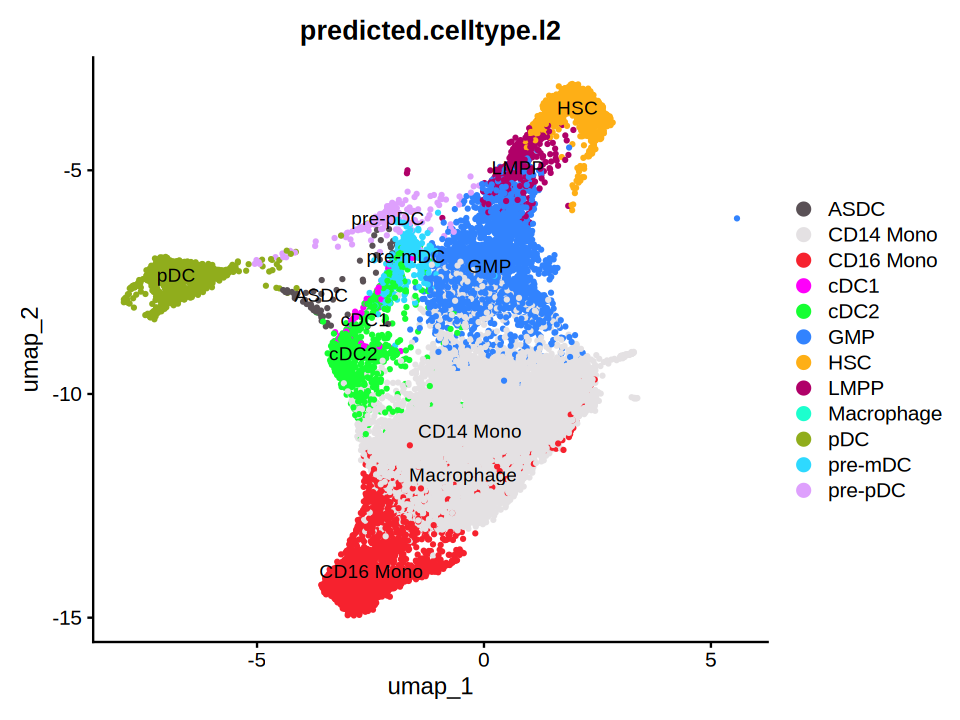

In [26]:
library(scCustomize)
options(repr.plot.height=6,repr.plot.width=8)
DimPlot_scCustom(bm_anno_myeloid, pt.size=0.5,reduction = "umap", group.by = c("predicted.celltype.l2"),label=T) 

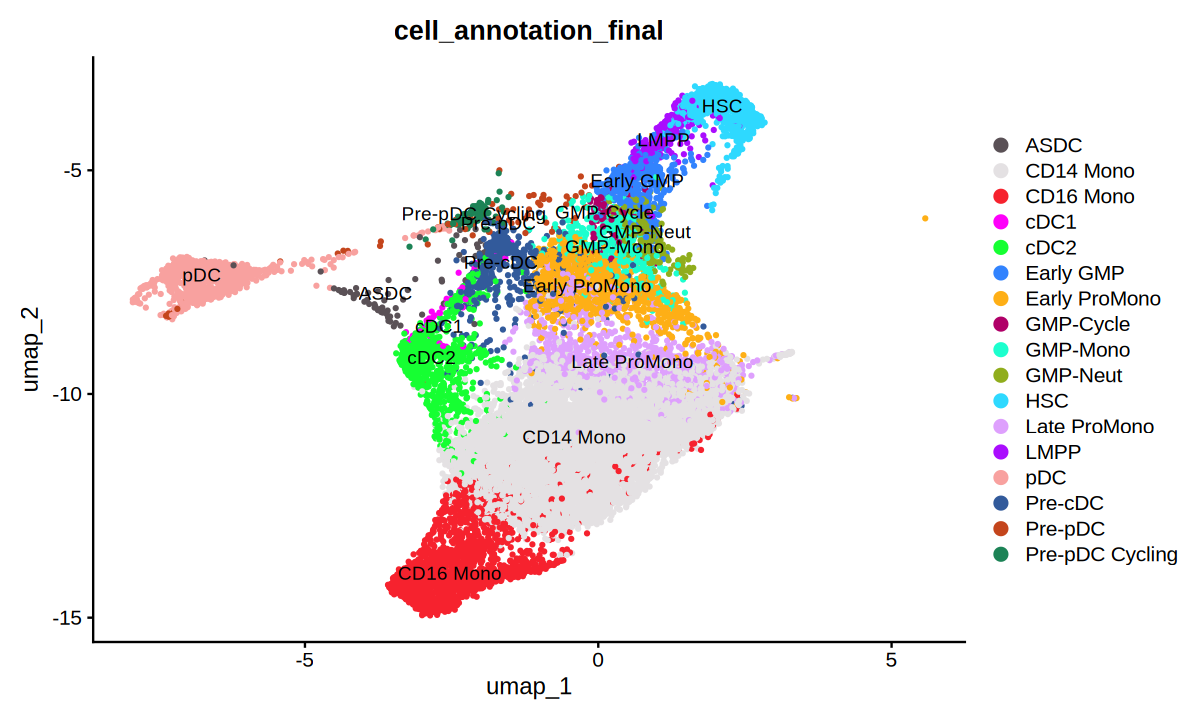

In [27]:
library(scCustomize)
options(repr.plot.height=6,repr.plot.width=10)
DimPlot_scCustom(bm_anno_myeloid, pt.size=0.5,reduction = "umap", group.by = c("cell_annotation_final"),label=T) 

In [28]:
library(dplyr)

mlab <- as.character(bm_anno_myeloid$predicted.celltype.l2)
lab0 <- as.character(bm_anno_myeloid$cell_annotation_final)

final <- case_when(
  !is.na(lab0) & lab0 == "Colony Forming Unit-Monocytes" ~ "Colony Forming Unit-Monocytes",
  !is.na(lab0) & lab0 == "Colony Forming Unit-Granulocytes" ~ "Colony Forming Unit-Granulocytes",
  !is.na(lab0) & lab0 == "Granulocytes (Neutrophils)" ~ "Granulocytes (Neutrophils)",
  TRUE ~ mlab   # default: keep multinomial label
)

# fallback: if final is NA/blamyeloid, use original label
final[is.na(final) | final == ""] <- lab0[is.na(final) | final == ""]

bm_anno_myeloid$final_label <- factor(final, levels = sort(unique(final)))


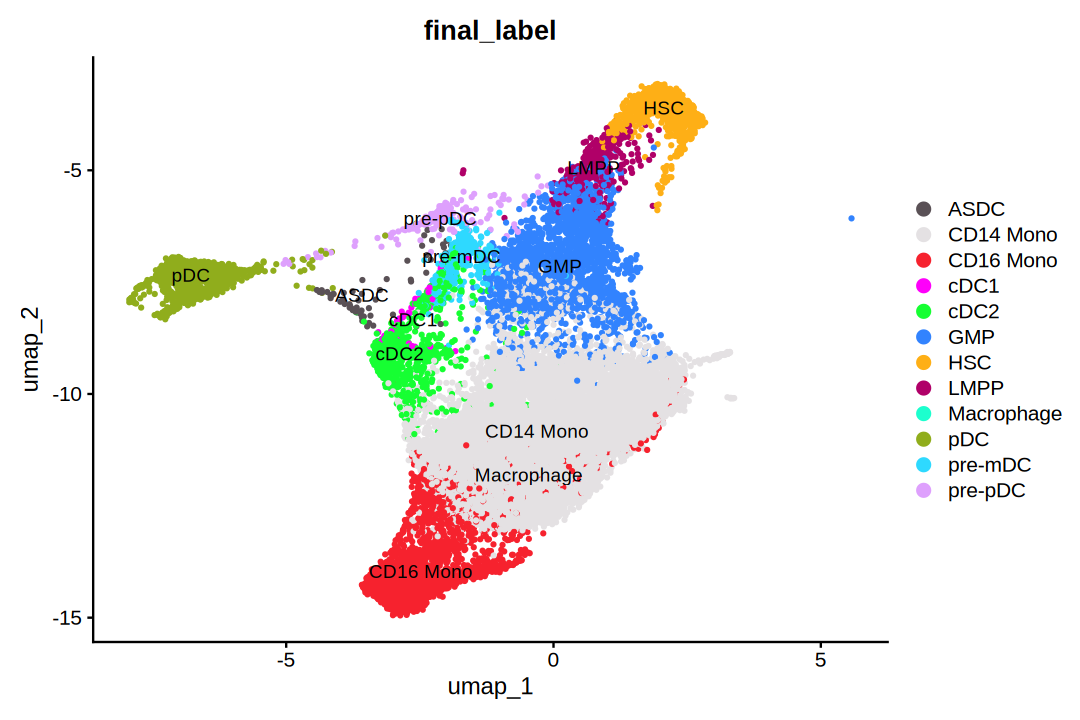

In [29]:
library(scCustomize)
options(repr.plot.height=6,repr.plot.width=9)
DimPlot_scCustom(bm_anno_myeloid, pt.size=0.5,reduction = "umap", group.by = c("final_label"),label=T) 

## 6. Visualization and figure generation


In [30]:
Idents(bm_anno_myeloid) <- "final_label"  

# Create a custom blue to yellow color palette
blue_red_palette <- colorRampPalette(c("steelblue", "white", "firebrick"))

# Define a color vector with 26 colors
cols_vec <- colorRampPalette(c("steelblue", "white", "firebrick"))(26)

# all marker
allgene <- c(
    #HSC
    "CD34",
    # mono/macro
    "VCAN","THBS1","S1PR3","CD36","ALDH1A1","CYP1B1","NRG1",
    # neutrophil
    "CXCR1","CXCR2","FCGR3B","MME","PI3","G0S2",
    # immature
    "MPO","ELANE","PRTN3","AZU1","CTSG","DEFA4","OLR1",
    # mature
    "FCGR3B","MME","CXCR1","CXCR2","CEACAM8",
    # proliferating
    "CDC20","UBE2C","BIRC5","CENPA",
    # kuffer-like?cDC2?
    "CD14","CD163","CLEC10A","NOTCH2","ITGAM","SIRPA","CX3CR1","CD1C",
    # dendritic
    "CD1C","CD1E","FCER1A","CLEC10A","CCR6","NDRG2","PKIB","GRIP1","XCR1",
    # plasmatoid
    "CLEC4C","LILRB4","NRP1",
    "CD38"
)



In [31]:
library(RColorBrewer)

# Define a color vector with 26 colors
cols_vec <- colorRampPalette(c("steelblue", "white", "firebrick"))(26)

# Use DotPlot with the color palette

# Re-run DotPlot with deduplicated genes
initial_plot <- DotPlot(bm_anno_myeloid, features = unique(allgene), scale = TRUE, cols = cols_vec)

# Extract and plot
plot_data <- initial_plot$data


Warning message:
"The following requested variables were not found: PI3"



Attaching package: 'reshape2'


The following object is masked from 'package:tidyr':

    smiths




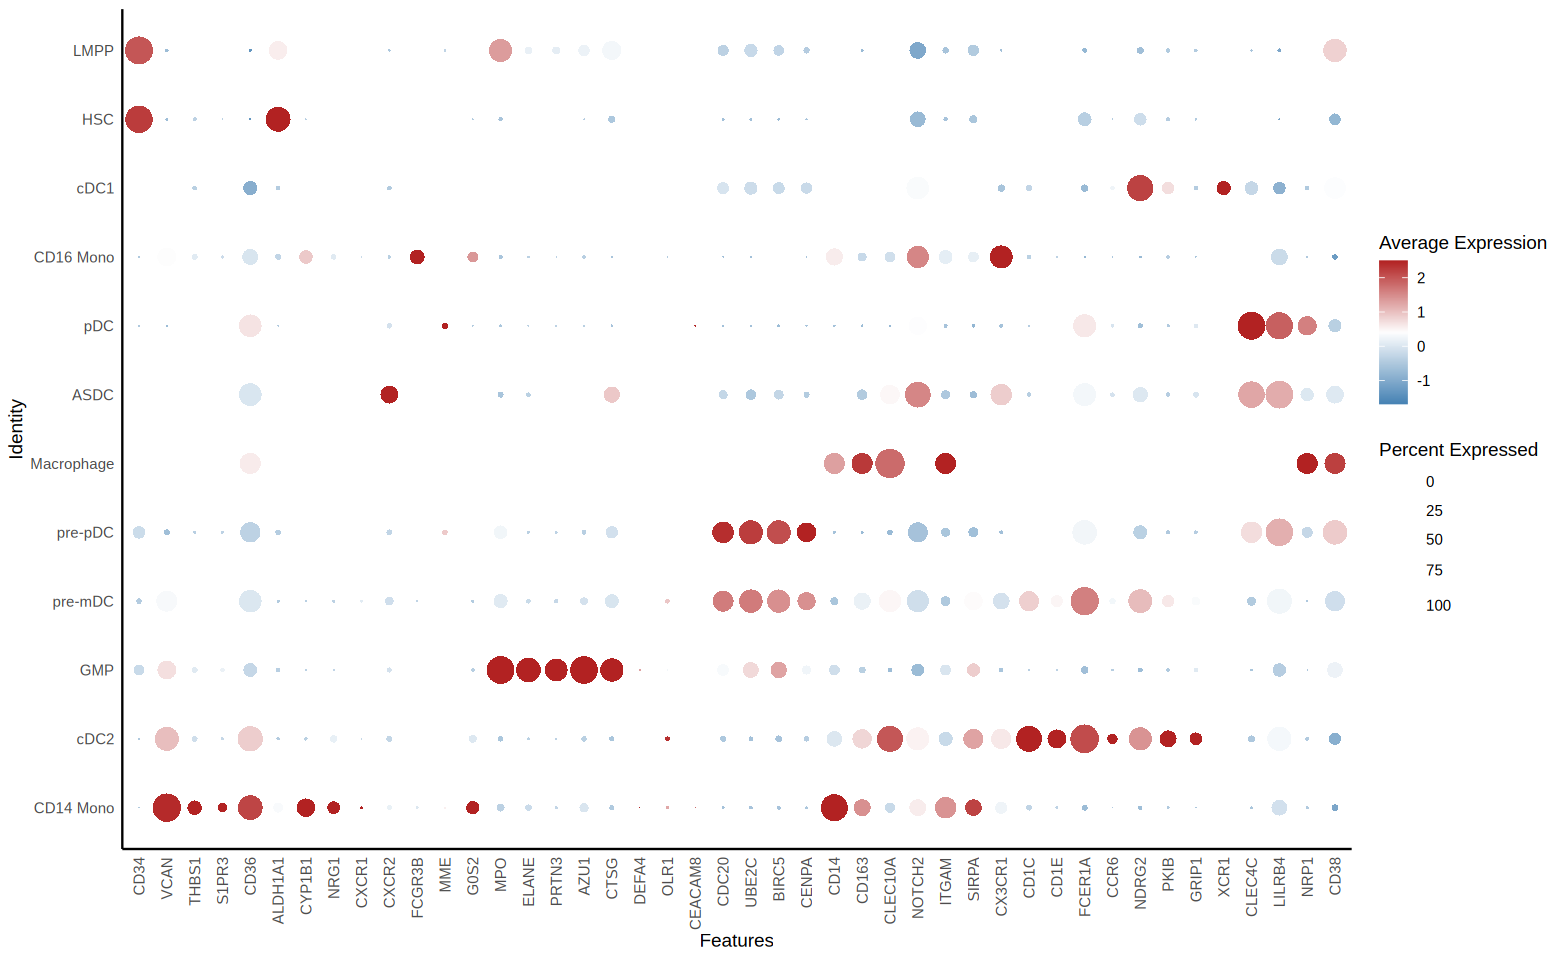

In [32]:
options(repr.plot.height=8,repr.plot.width=13)
library(pheatmap)  # For clustering
library(reshape2)  # For reshaping

# Pivot the data to get matrix for clustering (avg.exp.scaled by id and feature)
mat <- reshape2::dcast(plot_data, id ~ features.plot, value.var = "avg.exp.scaled")
rownames(mat) <- mat$id
mat$id <- NULL

# Hierarchical clustering of ids (rows)
clust <- hclust(dist(mat))
new_order <- clust$labels[clust$order]  # ordered row names

# Reorder the id factor in plot_data
plot_data$id <- factor(plot_data$id, levels = new_order)

# Rebuild the plot
p <- ggplot(plot_data, aes(x = features.plot, y = id)) +
  geom_point(aes(size = pct.exp, fill = avg.exp.scaled), shape = 21, color = "black", stroke = 0) +
  scale_size(range = c(0, 8), name = "Percent Expressed") +
  scale_fill_gradientn(colors = blue_red_palette(100), name = "Average Expression") +
  theme_minimal() +
  theme(
    axis.text.x = element_text(angle = 90, hjust = 1, vjust = 0.5),
    panel.grid.major = element_blank(),
    panel.grid.minor = element_blank(),
    panel.background = element_blank(),
    axis.line = element_line(color = "black")
  ) +
  labs(x = "Features", y = "Identity")

p


## 7. Packages and reproducibility setup


In [33]:
library(msigdbr)
library(dplyr)
library(readr)

monocytes <- msigdbr(species = "Homo sapiens", category = "C5", subcategory = "BP") %>%
  filter(gs_name == "GOBP_MONOCYTE_CHEMOTAXIS") %>%
  distinct(gene_symbol)

neutrophils <- msigdbr(species = "Homo sapiens", category = "C5", subcategory = "BP") %>%
  filter(gs_name == "GOBP_NEUTROPHIL_CHEMOTAXIS") %>%
  distinct(gene_symbol)

write_csv(monocytes, "GO_monocyte_chemotaxis_genes_MSigDB.csv")
write_csv(neutrophils,   "GO_neutrophil_chemotaxis_genes_MSigDB.csv")


Loading required package: grid

Loading required package: futile.logger



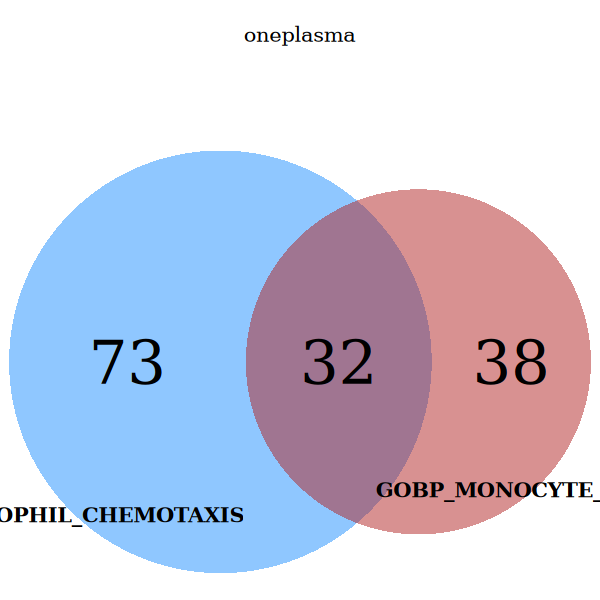

In [34]:
library(VennDiagram)
options(repr.plot.height=5,repr.plot.width=5)
input<-list(monocytes$"gene_symbol",neutrophils$"gene_symbol")
Table<-calculate.overlap(input)
venn<-venn.diagram(main='oneplasma',input,NULL, cat.fontface = "bold",cat.cex = 1,cex = 3,
category = c('GOBP_MONOCYTE_CHEMOTAXIS',"GOBP_NEUTROPHIL_CHEMOTAXIS"),fill = c( "firebrick",'dodgerblue'),lty='blank',
cat.col= 'black',   imagetype = "tiff",  main.fontfamily="serif") #, filename = "Vennup.tif"
grid.draw(venn)

$a1
 [1] "AIF1"         "ANO6"         "ANXA1"        "CALCA"        "CCL1"        
 [6] "CCL11"        "CCL13"        "CCL14"        "CCL15"        "CCL16"       
[11] "CCL17"        "CCL18"        "CCL19"        "CCL2"         "CCL20"       
[16] "CCL21"        "CCL22"        "CCL23"        "CCL24"        "CCL25"       
[21] "CCL26"        "CCL3"         "CCL3L1"       "CCL3L3"       "CCL4"        
[26] "CCL5"         "CCL7"         "CCL8"         "CCN3"         "CCR1"        
[31] "CCR2"         "CREB3"        "CTSG"         "CX3CL1"       "CX3CR1"      
[36] "CXCL10"       "CXCL12"       "CXCL17"       "DEFB104A"     "DEFB104B"    
[41] "DEFB124"      "DUSP1"        "FLT1"         "FOLR2"        "FPR2"        
[46] "GREM1"        "HMGB1"        "IL6"          "IL6R"         "LGALS3"      
[51] "LGMN"         "LYN"          "MICOS10-NBL1" "MOSPD2"       "MSMP"        
[56] "NBL1"         "PDGFB"        "PLA2G7"       "PTPRO"        "RPS19"       
[61] "S100A12"      "S100A14"      "

pdf 
  2

pdf 
  2

Saved: Vennup.tif and Vennup.pdf



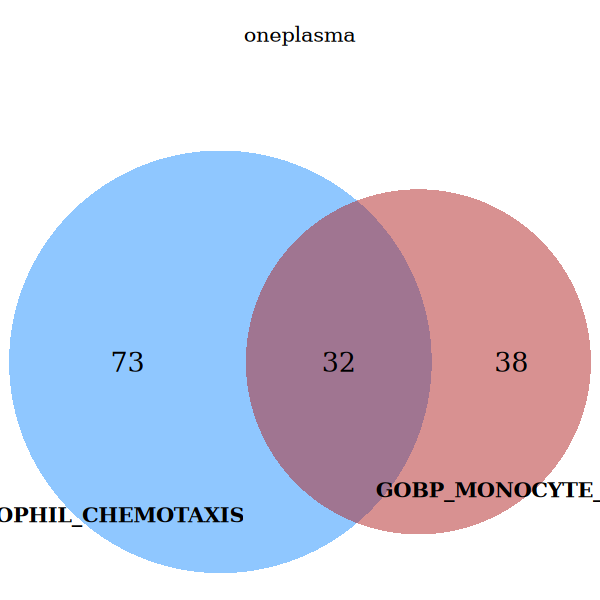

In [35]:
suppressPackageStartupMessages({
  library(VennDiagram)
  library(grid)
})

options(repr.plot.height = 5, repr.plot.width = 5)

# ---------------------------
# Inputs
# ---------------------------
input <- list(
  monocytes   = monocytes$gene_symbol,
  neutrophils = neutrophils$gene_symbol
)

# Optional: remove NAs/duplicates for cleaner counts
input <- lapply(input, function(x) unique(na.omit(x)))

# ---------------------------
# Compute overlap table (if you want it)
# ---------------------------
Table <- calculate.overlap(input)
print(Table)

# ---------------------------
# Draw to the active device (notebook)
# ---------------------------
venn <- venn.diagram(
  x = input,
  filename = NULL,                 # IMPORTANT: render to current device
  main = "oneplasma",
  category.names = c("GOBP_MONOCYTE_CHEMOTAXIS", "GOBP_NEUTROPHIL_CHEMOTAXIS"),
  cat.fontface = "bold",
  cat.cex = 1,
  cex = 1.3,                       # text size inside circles
  fill = c("firebrick", "dodgerblue"),
  lty = "blank",
  cat.col = "black",
  main.fontfamily = "serif"
)

grid.newpage()
grid.draw(venn)

# ---------------------------
# Export as TIFF (recommended for journals)
# ---------------------------
out_tiff <- "Vennup.tif"
tiff(out_tiff, width = 1600, height = 1600, res = 300, compression = "lzw")
grid.newpage()
grid.draw(venn)
dev.off()

# ---------------------------
# (Optional) Export as PDF too
# ---------------------------
out_pdf <- "Vennup.pdf"
pdf(out_pdf, width = 5, height = 5)
grid.newpage()
grid.draw(venn)
dev.off()

message("Saved: ", out_tiff, " and ", out_pdf)


In [36]:
bm_anno_myeloid <- NormalizeData(
  bm_anno_myeloid,
  assay = "RNA",
  normalization.method = "LogNormalize",
  scale.factor = 10000,
  verbose = TRUE
)

Layers(bm_anno_myeloid[["RNA"]])

Normalizing layer: counts



[1] "data"       "counts"     "scale.data"

In [37]:
## ---- 0) Gene sets ----
geneset1 <- monocytes$"gene_symbol"     # mono/macrophage-like
geneset2 <- neutrophils$"gene_symbol"                 # neutrophil-like

## ---- 1) Add scores to the original object ----
# Columns will be Set11 and Set21 in meta.data
bm_anno_myeloid<- AddModuleScore(bm_anno_myeloid, features = list(geneset1), name = "Set1")
bm_anno_myeloid<- AddModuleScore(bm_anno_myeloid, features = list(geneset2), name = "Set2")


Warning message:
"The following features are not present in the object: CALCA, CCL1, CCL11, CCL13, CCL15, CCL17, CCL21, CCL3L3, CX3CL1, DEFB104A, DEFB104B, DEFB124, MICOS10-NBL1, S100A7, not searching for symbol synonyms"
Warning message:
"The following features are not present in the object: CCL1, CCL11, CCL13, CCL15, CCL17, CCL21, CCL3L3, CD300H, CX3CL1, LBP, MIR223, not searching for symbol synonyms"


## 8. Visualization and figure generation


Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
"conversion failure on 'Selected q1=0.50, q2=0.50  →  diag=36.4%' in 'mbcsToSbcs': dot substituted for <e2>"
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
"conversion failure on 'Selected q1=0.50, q2=0.50  →  diag=36.4%' in 'mbcsToSbcs': dot substituted for <86>"
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
"conversion failure on 'Selected q1=0.50, q2=0.50  →  diag=36.4%' in 'mbcsToSbcs': dot substituted for <92>"
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
"conversion failure on 'Selected q1=0.50, q2=0.50  →  diag=36.4%' in 'mbcsToSbcs': dot substituted for <e2>"
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
"conversion failure on 'Selected q1=0.50, q2=0.50  →  diag=36.4%' in 'mbcsToSbcs': dot substituted for <86>"
Warning message in grid.Call.graphics(C

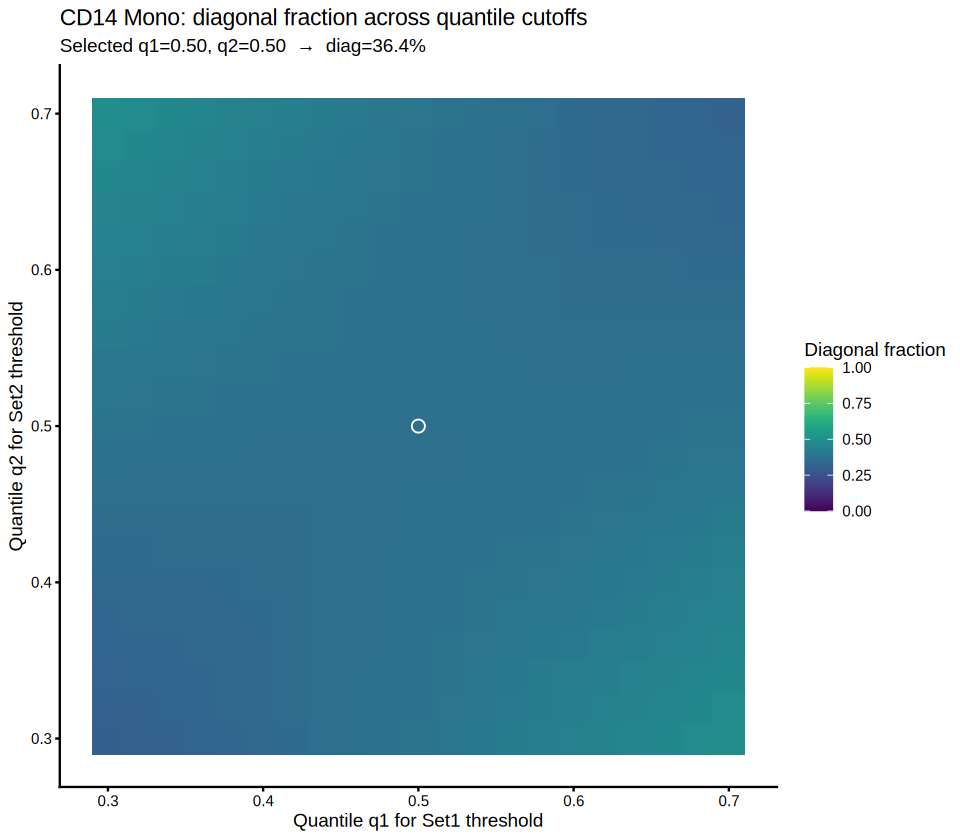

Final (per-set) diagonal fraction in CD14 Mono: 36.4%




set1High_set2High  set1High_set2Low  set1Low_set2High   set1Low_set2Low 
             3613              2071              2071              3612 


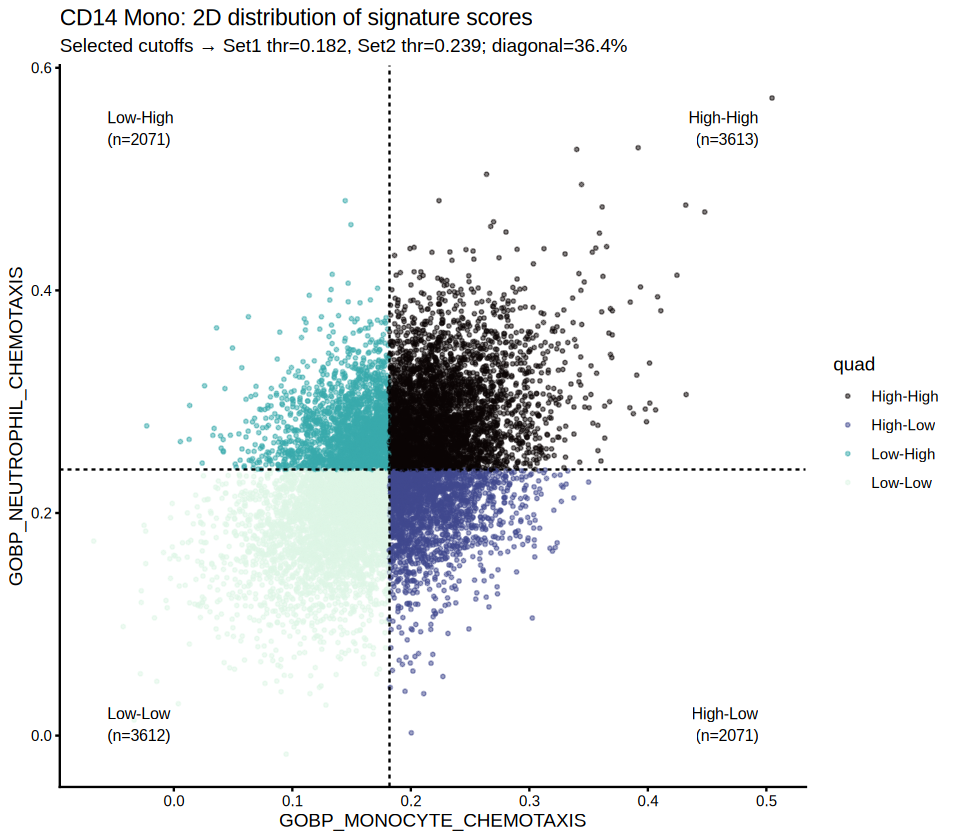

In [38]:
suppressPackageStartupMessages({
  library(dplyr)
  library(tidyr)
  library(ggplot2)
  library(viridis)
  library(purrr)
})

options(repr.plot.height=7, repr.plot.width=8)

# ======================== CONFIG =========================
anno_col   <- "final_label"
cell_type  <- "CD14 Mono"
MODE       <- "maximize"   # "maximize" or "enforce"
TARGET     <- 0.60         # used when MODE == "enforce" (min diagonal fraction)
USE_DIFF_MODE <- TRUE      # also try the |Set1-Set2| gap method

# ==================== PREPARE DATA =======================
is_ct <- bm_anno_myeloid@meta.data[[anno_col]] == cell_type

df <- bm_anno_myeloid@meta.data %>%
  tibble::as_tibble(rownames = "cell") %>%
  filter(.data[[anno_col]] == !!cell_type) %>%
  transmute(cell,
            set1 = Set11,
            set2 = Set21) %>%
  filter(is.finite(set1), is.finite(set2))

stopifnot(nrow(df) > 0)

use_hex <- nrow(df) > 20000

# Helper: compute diagonal fraction for given numeric thresholds
diag_prop_from_thresholds <- function(s1, s2, thr1, thr2) {
  lab1 <- ifelse(s1 >= thr1, "set1High", "set1Low")
  lab2 <- ifelse(s2 >= thr2, "set2High", "set2Low")
  mean((lab1 == "set1High" & lab2 == "set2Low") |
       (lab1 == "set1Low"  & lab2 == "set2High"),
       na.rm = TRUE)
}

# ================== GRID OVER QUANTILES ==================
s1 <- df$set1; s2 <- df$set2
q_grid1 <- seq(0.30, 0.70, by = 0.02)
q_grid2 <- seq(0.30, 0.70, by = 0.02)

grid_tbl <- tidyr::crossing(q1 = q_grid1, q2 = q_grid2) %>%
  mutate(
    thr1 = as.numeric(map_dbl(q1, ~ quantile(s1, .x, na.rm = TRUE))),
    thr2 = as.numeric(map_dbl(q2, ~ quantile(s2, .x, na.rm = TRUE))),
    prop_diag = pmap_dbl(list(thr1, thr2), ~ diag_prop_from_thresholds(s1, s2, ..1, ..2)),
    dist_to_med = abs(q1 - 0.5) + abs(q2 - 0.5)  # used for tie-breakers / "enforce"
  )

# ======== FORCE MEDIAN CUTOFFS ON X & Y (Set1, Set2) ========
thr1 <- median(s1, na.rm = TRUE)
thr2 <- median(s2, na.rm = TRUE)
prop_diag_q <- diag_prop_from_thresholds(s1, s2, thr1, thr2)

# keep a fake "best_row" at q1=q2=0.5 so the heatmap still shows a white dot at the median
best_row <- tibble::tibble(
  q1 = 0.50, q2 = 0.50,
  thr1 = thr1, thr2 = thr2,
  prop_diag = prop_diag_q,
  dist_to_med = 0
)


# ============== HEATMAP of diagonal proportion ===========
p_heat <- ggplot(grid_tbl, aes(q1, q2, fill = prop_diag)) +
  geom_tile() +
  scale_fill_viridis(name = "Diagonal fraction", limits = c(0,1)) +
  geom_point(data = best_row, aes(q1, q2), color = "white", size = 3, shape = 21, stroke = 0.6) +
  labs(x = "Quantile q1 for Set1 threshold",
       y = "Quantile q2 for Set2 threshold",
       title = paste0(cell_type, ": diagonal fraction across quantile cutoffs"),
       subtitle = sprintf("Selected q1=%.2f, q2=%.2f  →  diag=%.1f%%",
                          best_row$q1, best_row$q2, 100*prop_diag_q)) +
  theme_classic()

# ============== SCATTER/HEX with chosen thresholds ==========
# Quadrant labeling for the chosen thr1, thr2
df_quads <- df %>%
  mutate(
    quad = case_when(
      set1 >= thr1 & set2 >= thr2 ~ "High-High",
      set1 >= thr1 & set2 <  thr2 ~ "High-Low",
      set1 <  thr1 & set2 >= thr2 ~ "Low-High",
      TRUE                        ~ "Low-Low"
    )
  )

qcounts <- df_quads %>%
  count(quad) %>%
  tidyr::complete(quad = c("High-High","High-Low","Low-High","Low-Low"), fill = list(n = 0))

padx <- (max(df$set1, na.rm=TRUE) - min(df$set1, na.rm=TRUE)) * 0.02
pady <- (max(df$set2, na.rm=TRUE) - min(df$set2, na.rm=TRUE)) * 0.02

labpos <- tibble::tibble(
  quad = c("High-High","High-Low","Low-High","Low-Low"),
  x = c(max(df$set1, na.rm=TRUE) - padx, max(df$set1, na.rm=TRUE) - padx,
        min(df$set1, na.rm=TRUE) + padx, min(df$set1, na.rm=TRUE) + padx),
  y = c(max(df$set2, na.rm=TRUE) - pady, min(df$set2, na.rm=TRUE) + pady,
        max(df$set2, na.rm=TRUE) - pady, min(df$set2, na.rm=TRUE) + pady),
  hjust = c(1,1,0,0),
  vjust = c(1,0,1,0)
) %>% left_join(qcounts, by = "quad") %>%
  mutate(label = paste0(quad, "\n(n=", n, ")"))

p_scatter <- ggplot(df_quads, aes(x = set1, y = set2)) +
  { if (use_hex) geom_hex(bins = 50, alpha = 0.9) else
      geom_point(aes(color = quad), alpha = 0.5, size = 0.6) } +
  geom_vline(xintercept = thr1, linetype = "dashed") +
  geom_hline(yintercept = thr2, linetype = "dashed") +
  labs(x = "GOBP_MONOCYTE_CHEMOTAXIS", y = "GOBP_NEUTROPHIL_CHEMOTAXIS",
       title = paste0(cell_type, ": 2D distribution of signature scores"),
       subtitle = sprintf("Selected cutoffs → Set1 thr=%.3f, Set2 thr=%.3f; diagonal=%.1f%%",
                          thr1, thr2, 100*prop_diag_q)) +
  theme_classic() +
  { if (use_hex) scale_fill_viridis_c(option = "mako") else
      scale_color_viridis_d(option = "mako") } +
  geom_text(data = labpos, aes(x = x, y = y, label = label, hjust = hjust, vjust = vjust),
            size = 3.2)


# ================== PRINT / SAVE ==================
print(p_heat)
print(p_scatter)

# ================== WRITE TAGS BACK (optional) =================
# Use the selected per-set thresholds (q1,q2) for labeling
grp1_all <- ifelse(bm_anno_myeloid@meta.data$Set11 >= thr1, "set1High", "set1Low")
grp2_all <- ifelse(bm_anno_myeloid@meta.data$Set21 >= thr2, "set2High", "set2Low")

orig_lab <- as.character(bm_anno_myeloid@meta.data[[anno_col]])
tag_lab  <- ifelse(bm_anno_myeloid@meta.data[[anno_col]] == cell_type,
                   paste0(cell_type, "_", grp1_all, "_", grp2_all),
                   orig_lab)

bm_anno_myeloid$CD14_tag <- NA_character_
bm_anno_myeloid$CD14_tag[is_ct] <- paste0(grp1_all[is_ct], "_", grp2_all[is_ct])
bm_anno_myeloid$Annotation <- tag_lab

# Quick sanity checks
tab_cd14 <- table(bm_anno_myeloid$CD14_tag[is_ct], useNA = "ifany")
diag_prop_final <- sum(tab_cd14[c("set1High_set2Low","set1Low_set2High")], na.rm = TRUE) / sum(tab_cd14)
message(sprintf("Final (per-set) diagonal fraction in %s: %.1f%%", cell_type, 100*diag_prop_final))
print(tab_cd14)



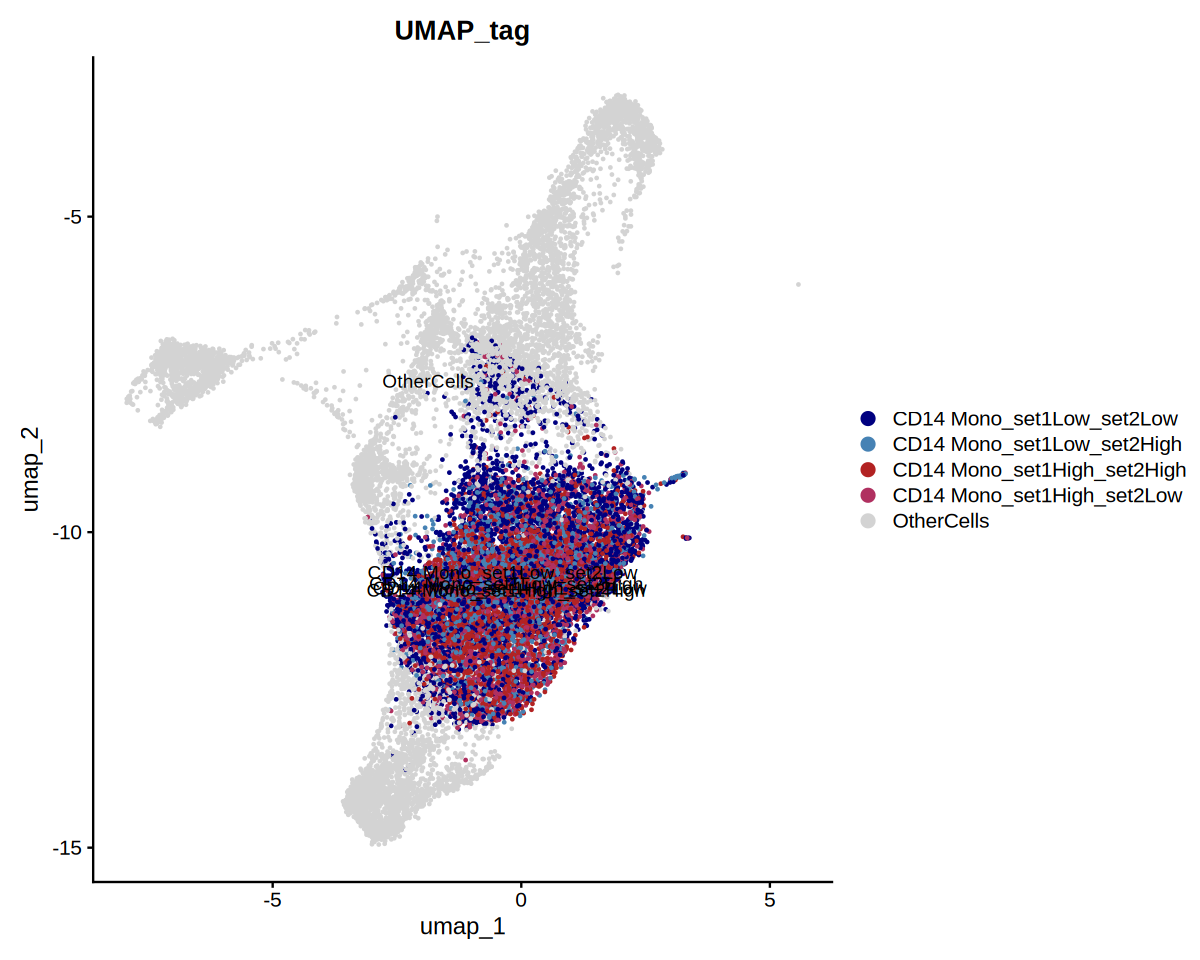

In [39]:
options(repr.plot.height = 8, repr.plot.width = 10)

# 1) Collapse non-CD14 to one label
bm_anno_myeloid$UMAP_tag <- ifelse(
  grepl("^CD14 Mono", bm_anno_myeloid$Annotation),
  bm_anno_myeloid$Annotation,
  "OtherCells"
)

# 2) Get CD14 Mono levels in a stable order
labs        <- unique(bm_anno_myeloid$UMAP_tag)
tag_levels  <- grep("^CD14 Mono", labs, value = TRUE)

# 3) Build the requested color panel for tagged groups
base_panel  <- c("navy", "steelblue", "firebrick", "maroon")
tag_cols    <- base_panel[seq_len(min(length(tag_levels), length(base_panel)))]

# If more CD14 groups than colors, recycle (or swap to a longer panel as needed)
if (length(tag_levels) > length(tag_cols)) {
  tag_cols <- rep(base_panel, length.out = length(tag_levels))
}

# 4) Set plotting order: all CD14 groups first, then "OtherCells"
bm_anno_myeloid$UMAP_tag <- factor(
  bm_anno_myeloid$UMAP_tag,
  levels = c(tag_levels, "OtherCells")
)

# 5) Final palette (OtherCells = lightgrey)
plot_cols <- c(tag_cols, "lightgrey")

# 6) Plot
DimPlot(
  bm_anno_myeloid,
  group.by  = "UMAP_tag",
  reduction = "umap",
  cols      = plot_cols,
  label     = TRUE
)


In [40]:
library(Seurat)
library(scCustomize)
library(patchwork)
library(ggplot2)

# Same UMAP coordinate limits for both plots
umap_mat <- Embeddings(bm_anno_myeloid, reduction = "umap")
xlim_use <- range(umap_mat[, 1], na.rm = TRUE)
ylim_use <- range(umap_mat[, 2], na.rm = TRUE)

p1 <- DimPlot_scCustom(
  bm_anno_myeloid,
  pt.size   = 0.5,
  reduction = "umap",
  group.by  = "predicted.celltype.l2",
  label     = TRUE
) +
  NoLegend() +
  coord_fixed(xlim = xlim_use, ylim = ylim_use) +
  ggtitle("Predicted cell type L2")

p2 <- DimPlot(
  bm_anno_myeloid,
  group.by  = "UMAP_tag",
  reduction = "umap",
  cols      = plot_cols,
  label     = TRUE
) +
  NoLegend() +
  coord_fixed(xlim = xlim_use, ylim = ylim_use) +
  ggtitle("UMAP tag")

p_combined <- p1 + p2 + 
  plot_layout(ncol = 2, widths = c(1, 1))

ggsave(
  filename = "bm_anno_myeloid_umap_panels_same_size.pdf",
  plot     = p_combined,
  width    = 10,
  height   = 5,
  units    = "in",
  device   = cairo_pdf
)

## 9. Define your targets (as a proper character vector)


In [43]:
# 2) Define your targets (as a proper character vector)
targets <- c("CD14 Mono","CD16 Mono","ASDC","cDC1","cDC2",'Macrophage',"pDC","pre-mDC","pre-pDC")

Idents(bm_anno_myeloid)<-'final_label'

# 3) Compare with what's actually present
available <- levels(Idents(bm_anno_myeloid))
keep <- intersect(targets, available)
missing <- setdiff(targets, available)

if (length(keep) == 0) {
  stop(
    paste0(
      "None of the requested identities are present in Idents(bm_anno).\n",
      "Available identities:\n - ", paste(available, collapse = "\n - ")
    )
  )
}

if (length(missing) > 0) {
  message("These requested identities were NOT found and will be skipped: ",
          paste(missing, collapse = ", "))
}

# 4) Subset safely
sce1_monodc <- subset(bm_anno_myeloid, idents = keep)



          AL1           AL2           AL3           AL4           AL5 
         1420          2673          5169           638          1040 
          AL6           AL7           AL8           AL9 demux_doublet 
         1067          1178           669           570           270 
          HD1           HD3           HD5           HD8           nan 
         1044           218           300           472            11 

AL cells: 14424

HD cells: 2034

AL donor table:




 AL1  AL2  AL3  AL4  AL5  AL6  AL7  AL8  AL9 
1420 2673 5169  638 1040 1067 1178  669  570 


HD donor table:




 HD1  HD3  HD5  HD8 
1044  218  300  472 


pdf 
  2

Saved PDF: myeloid_DC_dotplot_AL_HD_all.pdf



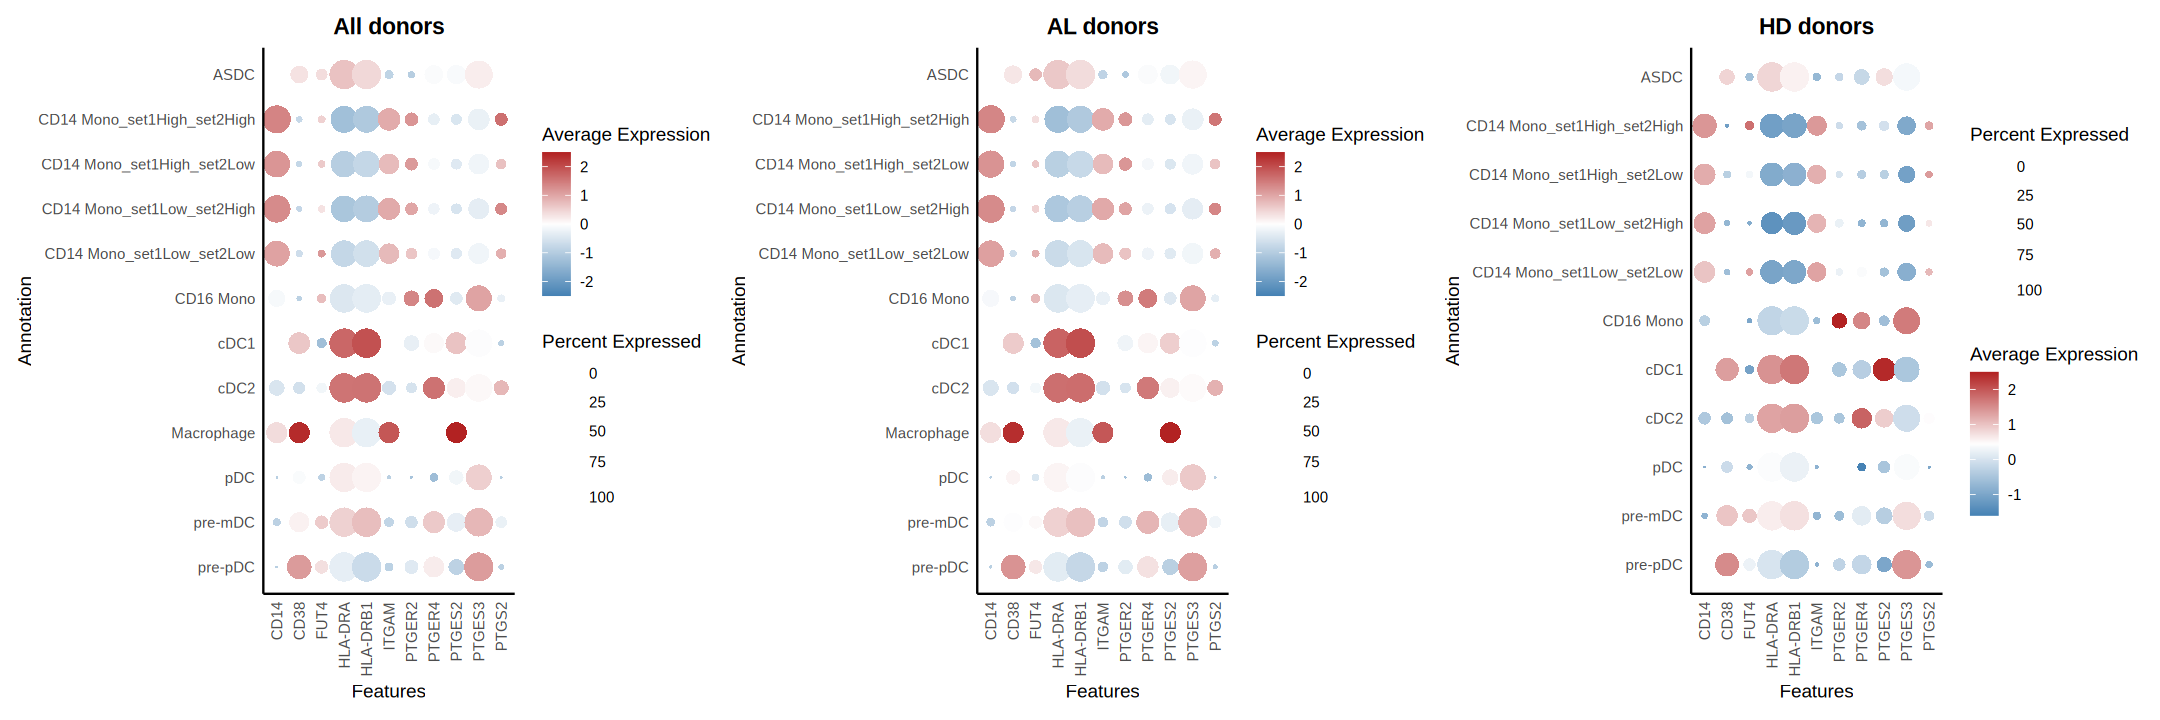

In [48]:
library(Seurat)
library(dplyr)
library(ggplot2)
library(RColorBrewer)
library(patchwork)

# ============================================================
# 1) Settings
# ============================================================

annotation_col <- "Annotation"
donor_col <- "donor_id_global"

stopifnot(annotation_col %in% colnames(sce1_monodc@meta.data))
stopifnot(donor_col %in% colnames(sce1_monodc@meta.data))

# Marker genes
allgene <- c(
  "CD38", "ITGAM", "CD14", "FUT4", "HLA-DRA", "HLA-DRB1",
  "PTGS2", "PTGER2", "PTGER4", "PTGES2", "PTGES3"
)

# Alphabetical gene order
allgene <- sort(unique(allgene))

# Keep only genes present in object
genes_found <- allgene[allgene %in% rownames(sce1_monodc)]
genes_missing <- setdiff(allgene, genes_found)

if (length(genes_missing) > 0) {
  message(
    "These requested genes were NOT found and will be skipped: ",
    paste(genes_missing, collapse = ", ")
  )
}

if (length(genes_found) == 0) {
  stop("None of the requested genes are present in sce1_monodc.")
}

allgene <- genes_found

# Color scale
cols_vec <- colorRampPalette(c("steelblue", "white", "firebrick"))(26)

blue_red_palette <- function(n) {
  colorRampPalette(c("steelblue", "white", "firebrick"))(n)
}

# ============================================================
# 2) Function to make alphabetically ordered DotPlot
# ============================================================

make_annotation_dotplot <- function(obj, plot_title) {
  
  if (ncol(obj) == 0) {
    message("Skipping ", plot_title, ": no cells.")
    return(NULL)
  }
  
  Idents(obj) <- annotation_col
  
  initial_plot <- DotPlot(
    obj,
    features = allgene,
    scale = TRUE,
    cols = cols_vec
  )
  
  plot_data <- initial_plot$data
  
  # Alphabetical feature order
  plot_data$features.plot <- factor(
    plot_data$features.plot,
    levels = allgene
  )
  
  # Alphabetical Annotation order
  # rev(sort()) makes the y-axis display A-to-Z from top to bottom
  annotation_order <- rev(sort(unique(as.character(plot_data$id))))
  
  plot_data$id <- factor(
    plot_data$id,
    levels = annotation_order
  )
  
  p <- ggplot(plot_data, aes(x = features.plot, y = id)) +
    geom_point(
      aes(size = pct.exp, fill = avg.exp.scaled),
      shape = 21,
      color = "black",
      stroke = 0
    ) +
    scale_size(range = c(0, 8), name = "Percent Expressed") +
    scale_fill_gradientn(
      colors = blue_red_palette(100),
      name = "Average Expression"
    ) +
    scale_x_discrete(limits = allgene) +
    theme_minimal() +
    theme(
      axis.text.x = element_text(angle = 90, hjust = 1, vjust = 0.5),
      panel.grid.major = element_blank(),
      panel.grid.minor = element_blank(),
      panel.background = element_blank(),
      axis.line = element_line(color = "black"),
      plot.title = element_text(hjust = 0.5, face = "bold")
    ) +
    labs(
      title = plot_title,
      x = "Features",
      y = "Annotation"
    )
  
  return(p)
}

# ============================================================
# 3) Split cells by donor prefix
# ============================================================

table(sce1_monodc[[donor_col]][, 1])

cells_AL <- colnames(sce1_monodc)[
  grepl("^AL", as.character(sce1_monodc[[donor_col]][, 1]))
]

cells_HD <- colnames(sce1_monodc)[
  grepl("^HD", as.character(sce1_monodc[[donor_col]][, 1]))
]

sce1_monodc_AL <- subset(sce1_monodc, cells = cells_AL)
sce1_monodc_HD <- subset(sce1_monodc, cells = cells_HD)

message("AL cells: ", ncol(sce1_monodc_AL))
message("HD cells: ", ncol(sce1_monodc_HD))

# Confirm donor composition
message("AL donor table:")
print(table(sce1_monodc_AL[[donor_col]][, 1]))

message("HD donor table:")
print(table(sce1_monodc_HD[[donor_col]][, 1]))

# ============================================================
# 4) Generate plots
# ============================================================

p_all <- make_annotation_dotplot(
  sce1_monodc,
  plot_title = "All donors"
)

p_AL <- make_annotation_dotplot(
  sce1_monodc_AL,
  plot_title = "AL donors"
)

p_HD <- make_annotation_dotplot(
  sce1_monodc_HD,
  plot_title = "HD donors"
)

plot_list <- list(
  All = p_all,
  AL = p_AL,
  HD = p_HD
)

plot_list <- plot_list[!sapply(plot_list, is.null)]

# Combined overview page
p_combined <- wrap_plots(plot_list, ncol = 3)

# ============================================================
# 5) Save to same PDF
# ============================================================

out_pdf <- "myeloid_DC_dotplot_AL_HD_all.pdf"

pdf(out_pdf, width = 18, height = 6)

# Page 1: combined overview
print(p_combined)

# Page 2 onward: one plot per page
for (nm in names(plot_list)) {
  print(plot_list[[nm]])
}

dev.off()

message("Saved PDF: ", out_pdf)

# Show in notebook/RStudio
options(repr.plot.height = 6, repr.plot.width = 18)
p_combined